# Credit Risk Modeling: Static vs Sequential Approaches

Logistic Regression, Random Forest, XGBoost, LightGBM, and LSTM â€” binary default prediction on mobile money data.

## 1. Setup

In [41]:
import sys
import os

# Ensure seqcredit_model package is importable from notebooks directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from seqcredit_model.credit_model import (
    CreditRiskDataLoader, LogisticRegressionModel,
    XGBoostModel, RandomForestModel, LightGBMModel,
    LSTMModel, HybridLSTMModel, ModelEvaluator, set_random_seeds
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

set_random_seeds(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


## 2. Data Exploration

In [2]:
# Load raw data for exploration
df_features = pd.read_csv(os.path.join(project_root, 'data/user_features.csv'))
df_summaries = pd.read_csv(os.path.join(project_root, 'data/user_labels.csv'))

print(f'User features: {df_features.shape}')
print(f'User summaries: {df_summaries.shape}')
print(f'\nCredit risk label distribution (all users):')
print(df_summaries['credit_risk_label'].value_counts().sort_index())

User features: (10000, 30)
User summaries: (10000, 6)

Credit risk label distribution (all users):
credit_risk_label
-1    4048
 0    3241
 1    2050
 2     661
Name: count, dtype: int64


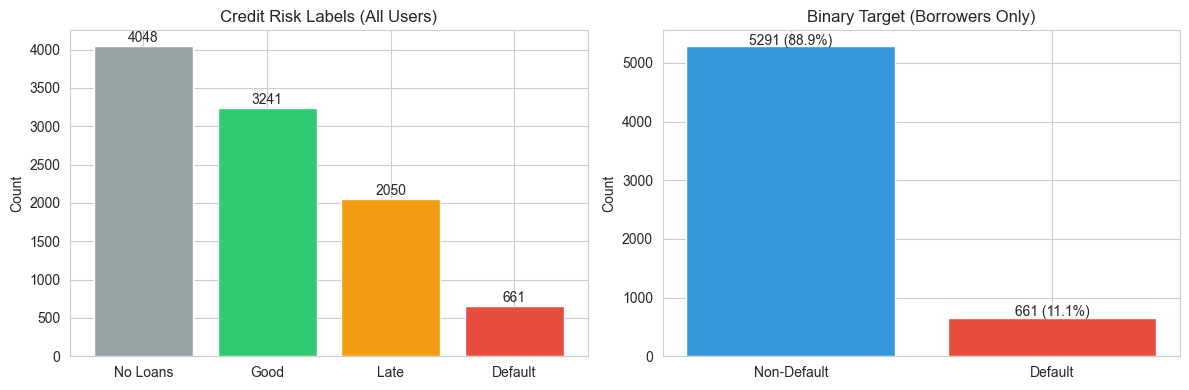


Total borrowers: 5952
Default rate: 0.111 (661 defaults)


In [3]:
# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# All users
labels_all = df_summaries['credit_risk_label'].value_counts().sort_index()
label_names = {-1: 'No Loans', 0: 'Good', 1: 'Late', 2: 'Default'}
ax1.bar([label_names[k] for k in labels_all.index], labels_all.values,
        color=['#95a5a6', '#2ecc71', '#f39c12', '#e74c3c'])
ax1.set_title('Credit Risk Labels (All Users)')
ax1.set_ylabel('Count')
for i, v in enumerate(labels_all.values):
    ax1.text(i, v + 50, str(v), ha='center')

# Borrowers only (binary target)
borrowers = df_summaries[df_summaries['credit_risk_label'] != -1]
binary = (borrowers['credit_risk_label'] == 2).astype(int)
counts = binary.value_counts().sort_index()
ax2.bar(['Non-Default', 'Default'], counts.values,
        color=['#3498db', '#e74c3c'])
ax2.set_title('Binary Target (Borrowers Only)')
ax2.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax2.text(i, v + 20, f'{v} ({v/len(borrowers)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

print(f'\nTotal borrowers: {len(borrowers)}')
print(f'Default rate: {binary.mean():.3f} ({binary.sum()} defaults)')

In [4]:
# Credit archetype distribution among borrowers
print('Credit archetypes (borrowers):')
print(borrowers['credit_archetype'].value_counts())

Credit archetypes (borrowers):
credit_archetype
responsible_borrower    3481
occasional_borrower     1516
risky_borrower           747
defaulter                208
Name: count, dtype: int64


## 3. Data Preparation

In [5]:
# Initialize data loader with paths relative to project root
loader = CreditRiskDataLoader(
    features_path=os.path.join(project_root, 'data/user_features.csv'),
    summaries_path=os.path.join(project_root, 'data/user_labels.csv'),
    transactions_dir=os.path.join(project_root, 'data/user_transactions'),
)

# Prepare static data splits
static_data = loader.prepare_static_splits()

print(f"Training samples: {len(static_data['y_train'])}")
print(f"Test samples: {len(static_data['y_test'])}")
print(f"Default rate (train): {static_data['y_train'].mean():.4f}")
print(f"Default rate (test): {static_data['y_test'].mean():.4f}")
print(f"Features: {len(static_data['feature_names'])}")
print(f"Scale pos weight: {loader.get_scale_pos_weight():.2f}")
print(f"\nFeature list:")
for i, name in enumerate(static_data['feature_names']):
    print(f"  {i+1:2d}. {name}")

[DataLoader] Validation passed: 10,000 matching users, label values=[np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Training samples: 4761
Test samples: 1191
Default rate (train): 0.1111
Default rate (test): 0.1108
Features: 40
Scale pos weight: 8.00

Feature list:
   1. obs_txn_count
   2. total_volume
   3. avg_transaction_amount
   4. median_transaction_amount
   5. std_transaction_amount
   6. max_transaction_amount
   7. min_transaction_amount
   8. cv_transaction_amount
   9. pct_transfers
  10. pct_debits
  11. pct_cashouts
  12. pct_payments
  13. avg_hours_between_txns
  14. pct_weekend_txns
  15. pct_night_txns
  16. pct_early_morning_txns
  17. avg_balance
  18. min_balance
  19. max_balance
  20. balance_volatility
  21. pct_low_balance_txns
  22. total_fees_paid
  23. avg_fees_per_txn
  24. pct_txns_with_fees
  25. unique_recipients
  26. recipient_concentration
  27. unique_txn_types
  28. account_age_days
  29. transactions_per_day
  30. loans_taken
  31. final_cre

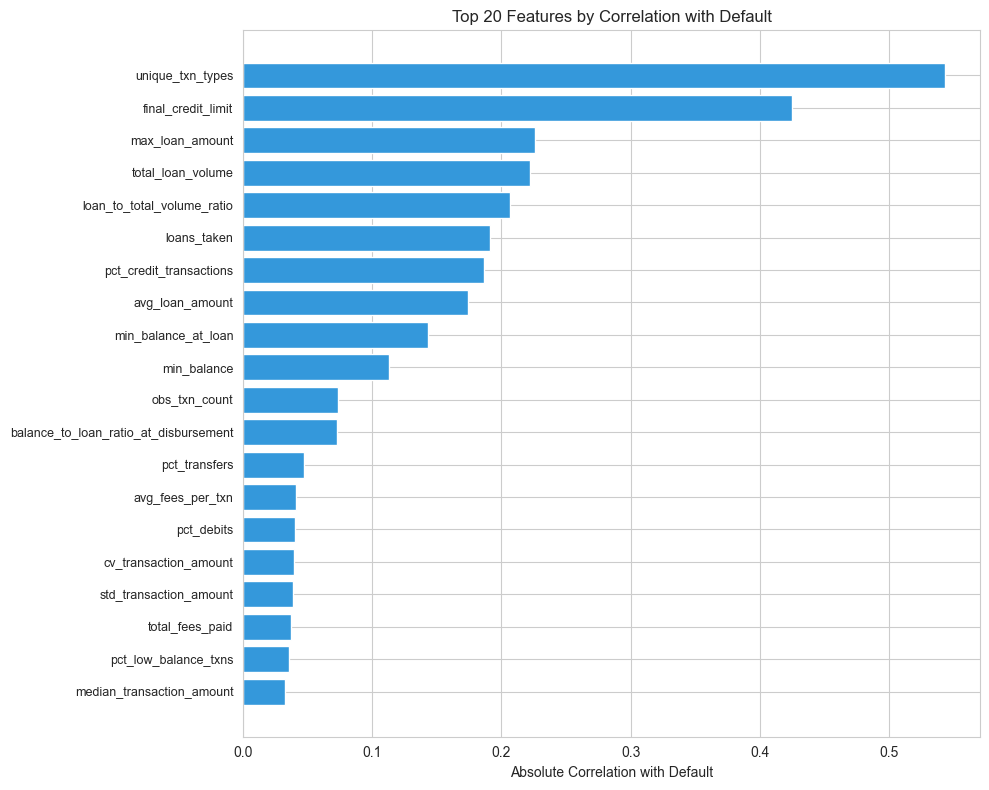

In [6]:
# Feature correlation with target (top features)
X_train_df = static_data['X_train'].copy()
X_train_df['default'] = static_data['y_train']
correlations = X_train_df.corr()['default'].drop('default').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = correlations.head(20)
ax.barh(range(len(top_corr)), top_corr.values, color='#3498db')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.set_xlabel('Absolute Correlation with Default')
ax.set_title('Top 20 Features by Correlation with Default')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Logistic Regression

In [7]:
# Train Logistic Regression
lr_model = LogisticRegressionModel(class_weight='balanced')
lr_model.fit(static_data['X_train_scaled'], static_data['y_train'])

# Cross-validation
print('Logistic Regression - 5-Fold Cross-Validation:')
lr_cv = lr_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in lr_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

Logistic Regression - 5-Fold Cross-Validation:
  auc_roc: 0.9808 +/- 0.0060
  auc_pr: 0.8641 +/- 0.0451
  f1: 0.7048 +/- 0.0284
  accuracy: 0.9099 +/- 0.0113


In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Test predictions
lr_proba = lr_model.predict_proba(static_data['X_test_scaled'])

print('Logistic Regression - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], lr_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], lr_proba):.4f}')

Logistic Regression - Test Set Performance:
  AUC-ROC: 0.9619
  AUC-PR: 0.7344


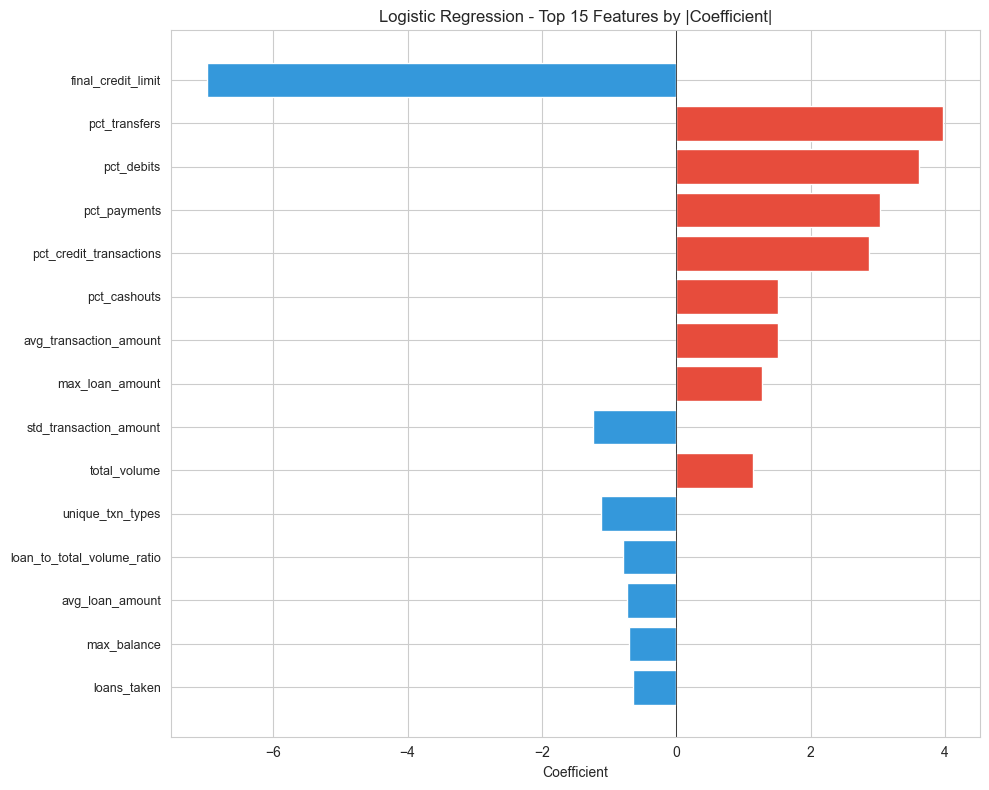

Red = increases default probability, Blue = decreases


In [9]:
# Feature coefficients
lr_coefs = lr_model.get_coefficients(static_data['feature_names'])

fig, ax = plt.subplots(figsize=(10, 8))
top_coefs = lr_coefs.head(15)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_coefs['coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'], color=colors)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'], fontsize=9)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression - Top 15 Features by |Coefficient|')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Red = increases default probability, Blue = decreases')

## 5. XGBoost Classifier

In [10]:
# Train XGBoost â€” carve a validation split from training data (no test leakage)
from sklearn.model_selection import train_test_split as tts
X_tr, X_val_xgb, y_tr, y_val_xgb = tts(
    static_data['X_train_scaled'], static_data['y_train'],
    test_size=0.15, stratify=static_data['y_train'], random_state=42
)
xgb_model = XGBoostModel(scale_pos_weight=loader.get_scale_pos_weight())
xgb_model.fit(X_tr, y_tr, X_val=X_val_xgb, y_val=y_val_xgb)

# Cross-validation
print('XGBoost - 5-Fold Cross-Validation:')
xgb_cv = xgb_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in xgb_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

XGBoost - 5-Fold Cross-Validation:
  auc_roc: 0.9812 +/- 0.0048
  auc_pr: 0.8984 +/- 0.0190
  f1: 0.7749 +/- 0.0162
  accuracy: 0.9479 +/- 0.0049


In [11]:
# Test predictions
xgb_proba = xgb_model.predict_proba(static_data['X_test_scaled'])

print('XGBoost - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], xgb_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], xgb_proba):.4f}')

XGBoost - Test Set Performance:
  AUC-ROC: 0.9783
  AUC-PR: 0.8708


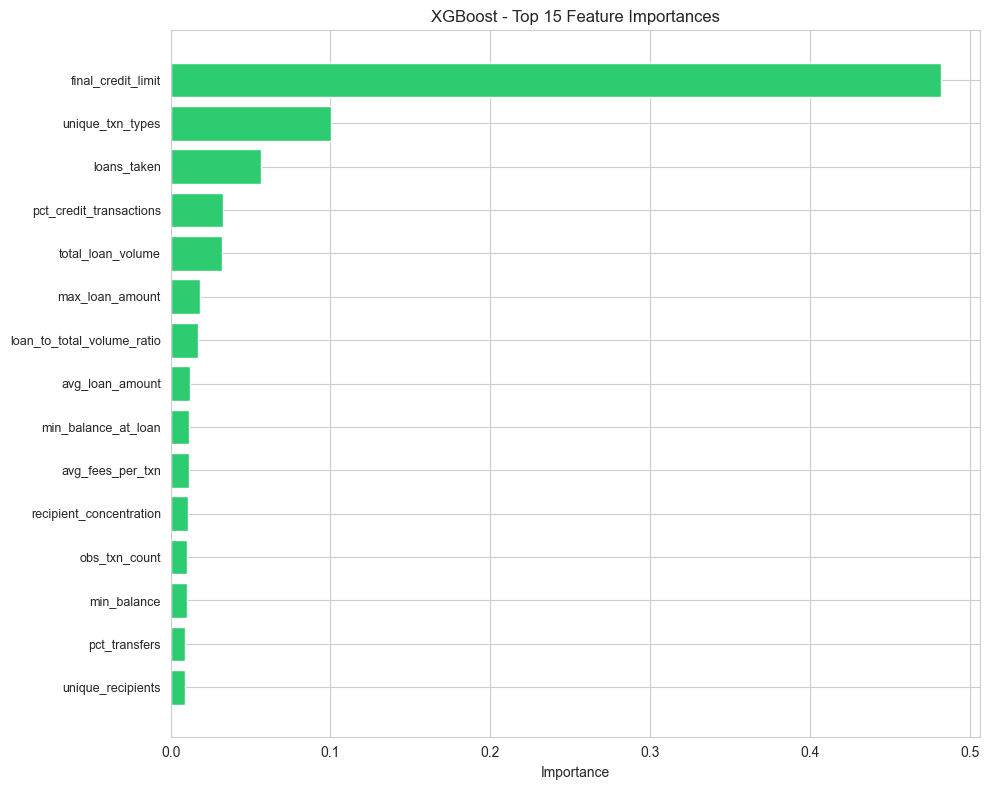

In [12]:
# Feature importance
xgb_importance = xgb_model.get_feature_importance(static_data['feature_names'])

fig, ax = plt.subplots(figsize=(10, 8))
top_imp = xgb_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#2ecc71')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('XGBoost - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Random Forest

Random Forest - 5-Fold Cross-Validation:
  auc_roc: 0.9807 +/- 0.0054
  auc_pr: 0.8908 +/- 0.0222
  f1: 0.7579 +/- 0.0314
  accuracy: 0.9443 +/- 0.0081

Random Forest - Test Set Performance:
  AUC-ROC: 0.9721
  AUC-PR: 0.8443


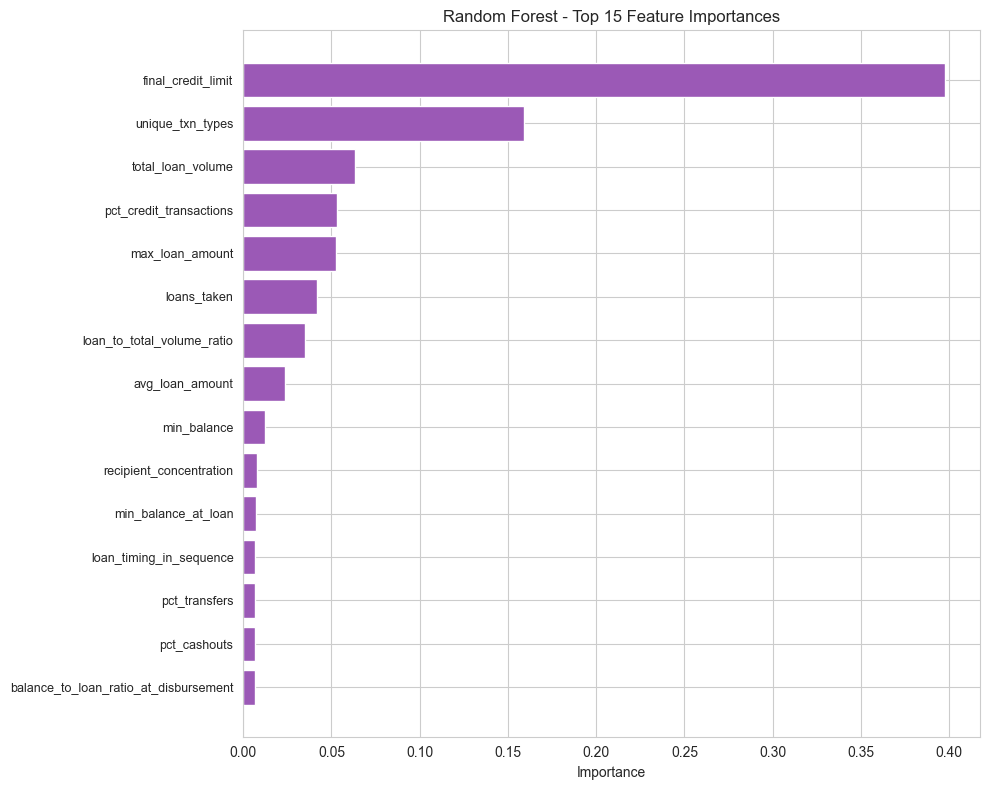

In [13]:
rf_model = RandomForestModel(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced'
)
rf_model.fit(static_data['X_train_scaled'], static_data['y_train'])

print('Random Forest - 5-Fold Cross-Validation:')
rf_cv = rf_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in rf_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

rf_proba = rf_model.predict_proba(static_data['X_test_scaled'])

print('\nRandom Forest - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], rf_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], rf_proba):.4f}')

rf_importance = rf_model.get_feature_importance(static_data['feature_names'])
fig, ax = plt.subplots(figsize=(10, 8))
top_imp = rf_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#9b59b6')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Random Forest - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. LightGBM


LightGBM - 5-Fold Cross-Validation:
  auc_roc: 0.9845 +/- 0.0031
  auc_pr: 0.9084 +/- 0.0161
  f1: 0.7839 +/- 0.0260
  accuracy: 0.9483 +/- 0.0063

LightGBM - Test Set Performance:
  AUC-ROC: 0.9820
  AUC-PR: 0.8778


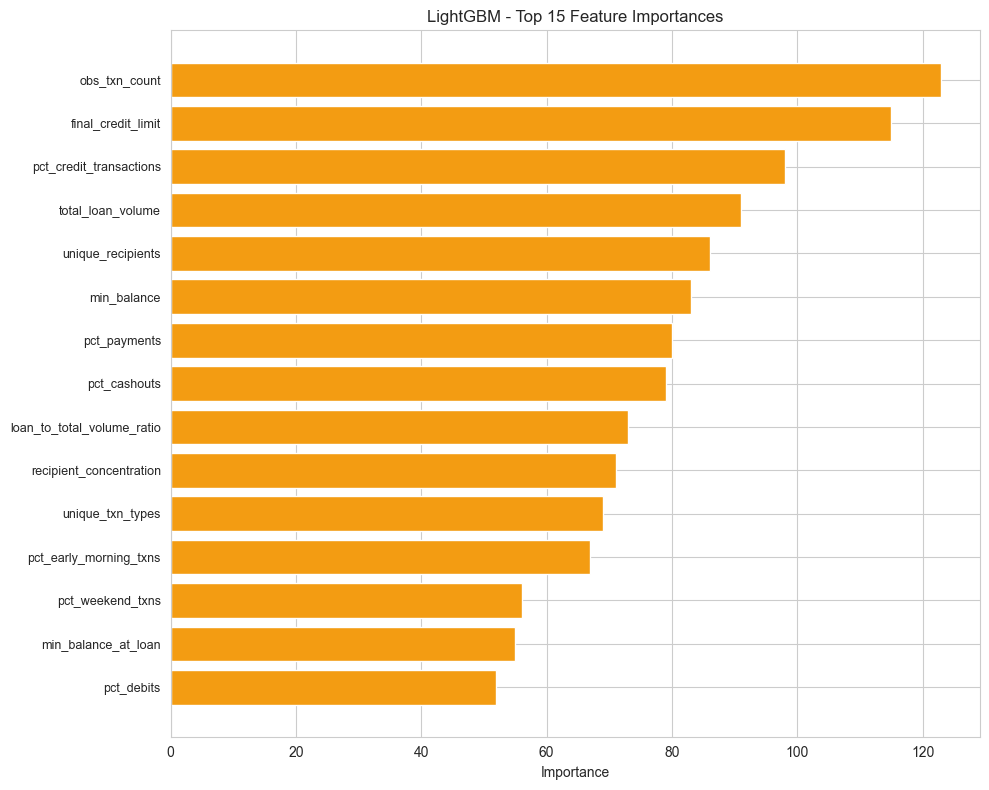

In [14]:
from sklearn.model_selection import train_test_split as tts

X_tr, X_val, y_tr, y_val = tts(
    static_data['X_train_scaled'], static_data['y_train'],
    test_size=0.15, stratify=static_data['y_train'], random_state=42
)

lgbm_model = LightGBMModel(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    num_leaves=31,
    class_weight='balanced'
)
lgbm_model.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

print('\nLightGBM - 5-Fold Cross-Validation:')
lgbm_cv = lgbm_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in lgbm_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

lgbm_proba = lgbm_model.predict_proba(static_data['X_test_scaled'])

print('\nLightGBM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], lgbm_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], lgbm_proba):.4f}')

lgbm_importance = lgbm_model.get_feature_importance(static_data['feature_names'])
fig, ax = plt.subplots(figsize=(10, 8))
top_imp = lgbm_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#f39c12')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('LightGBM - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. LSTM Models

Two architectures compared:
- **Sequential LSTM** â€” transaction sequences only
- **Hybrid LSTM** â€” sequences fused with static user features (early fusion)

In [15]:
# LSTM data preparation â€” builds sequence + static arrays aligned to the exact
# same train/test user split used by the static models (via loader._train/test_user_ids)
from seqcredit_model.feature_engineering import TemporalTransactionFeatureEngineer
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pathlib import Path

# Load sequences (used for feature_names reference; cache rebuilt if missing)
seq_data = loader.load_sequences(
    max_seq_len=100,
    cache_path=os.path.join(project_root, 'data/lstm_sequences.npz'),
)

# Reconstruct scaled static features for all borrowers (same feature set as static_data)
df_features_raw = pd.read_csv(os.path.join(project_root, 'data/user_features.csv'))
df_summaries_raw = pd.read_csv(os.path.join(project_root, 'data/user_labels.csv'))
df_merged = df_features_raw.merge(df_summaries_raw, on='user_id', how='inner')
df_merged = df_merged[df_merged['credit_risk_label'] != -1].copy()
df_merged['default'] = (df_merged['credit_risk_label'] == 2).astype(int)
df_merged = loader._engineer_loan_features(df_merged)

drop_cols = ['user_id', 'credit_risk_label', 'credit_archetype', 'default', 'gen_txn_count']
feature_cols = [c for c in df_merged.columns if c not in drop_cols]
X_all_lstm = StandardScaler().fit_transform(df_merged[feature_cols].values)
y_all_lstm = df_merged['default'].values
user_ids_lstm = df_merged['user_id'].values
user_to_idx = {uid: i for i, uid in enumerate(user_ids_lstm)}

transactions_path = Path(project_root) / 'data' / 'user_transactions'
engineer = TemporalTransactionFeatureEngineer()

def build_hybrid_data(user_id_set, max_seq_len=100):
    """Build aligned (sequence, static, label) arrays for a set of user IDs."""
    seq_list, static_list, label_list = [], [], []
    for uid in user_id_set:
        if uid not in user_to_idx:
            continue
        idx = user_to_idx[uid]
        filepath = transactions_path / f'{uid}.csv'
        if not filepath.exists():
            continue
        try:
            df_user = pd.read_csv(filepath)
            if df_user.empty or len(df_user) < 2:
                continue
            df_user['is_loan_disbursement'] = (df_user['TRANS. TYPE'] == 'CREDIT').astype(int)
            df_user['is_loan_repayment'] = (df_user['TRANS. TYPE'] == 'LOAN_REPAYMENT').astype(int)
            df_feat = engineer.extract_all_features(df_user)
            available_cols = [c for c in seq_data['feature_names'] if c in df_feat.columns]
            seq = df_feat[available_cols].values.astype(np.float32)
            seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
            seq_list.append(seq)
            static_list.append(X_all_lstm[idx])
            label_list.append(y_all_lstm[idx])
        except Exception:
            continue
    X_seq = pad_sequences(seq_list, maxlen=max_seq_len, padding='pre',
                          truncating='pre', dtype='float32', value=0.0)
    return X_seq, np.array(static_list), np.array(label_list)

print("Building training data...")
X_train_seq, X_train_static_lstm, y_train_lstm = build_hybrid_data(loader._train_user_ids)
print("Building test data...")
X_test_seq, X_test_static_lstm, y_test_lstm = build_hybrid_data(loader._test_user_ids)

print(f"\nTrain: seq {X_train_seq.shape}, static {X_train_static_lstm.shape}")
print(f"Test:  seq {X_test_seq.shape}, static {X_test_static_lstm.shape}")
print(f"Default rate â€” train: {y_train_lstm.mean():.4f}, test: {y_test_lstm.mean():.4f}")
assert len(y_test_lstm) == len(static_data['y_test']), \
    f"Test set size mismatch: LSTM {len(y_test_lstm)} vs static {len(static_data['y_test'])}"
print("Test set alignment confirmed.")

Processing 5952 borrower transaction files...
  Processed 1000/5952 users...
  Processed 2000/5952 users...
  Processed 3000/5952 users...
  Processed 4000/5952 users...
  Processed 5000/5952 users...
  Processed 5952/5952 users...
  Train: 4761, Test: 1191
Cached to c:\Users\Dell\Projects\seqcredit-model\data/lstm_sequences.npz
Shapes: train=(4761, 100, 38), test=(1191, 100, 38)
Building training data...
Building test data...

Train: seq (4761, 100, 38), static (4761, 40)
Test:  seq (1191, 100, 38), static (1191, 40)
Default rate â€” train: 0.1111, test: 0.1108
Test set alignment confirmed.


### 8a. Sequential LSTM

Class weights: {np.int64(0): np.float64(0.5625), np.int64(1): np.float64(4.5)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 100, 38)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 32)        │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,369 (48.32 KB)

 Trainable params: 12,369 (48.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 60s 297ms/step - auc: 0.4756 - loss: 0.7082 - val_auc: 0.4738 - val_loss: 0.6877 - learning_rate: 5.0000e-04
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - auc: 0.5152 - loss: 0.6994 - val_auc: 0.5339 - val_loss: 0.6916 - learning_rate: 5.0000e-04
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 298ms/step - auc: 0.4740 - loss: 0.7015 - val_auc: 0.5245 - val_loss: 0.6834 - learning_rate: 5.0000e-04
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 409ms/step - auc: 0.4959 - loss: 0.6989 - val_auc: 0.5164 - val_loss: 0.6803 - learning_rate: 5.0000e-04
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 68s 302ms/step - auc: 0.5039 - loss: 0.6984 - val_auc: 0.5059 - val_loss: 0.6826 - learning_rate: 5.0000e-04
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 303ms/step - auc: 0.5206 - loss: 0.6977 - val_auc: 0.5343 - val_loss: 0.6837 - learning_rate: 5.0000e-04
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 319ms/step - auc: 0.5113 - loss: 0.6985 - val_auc: 0.56

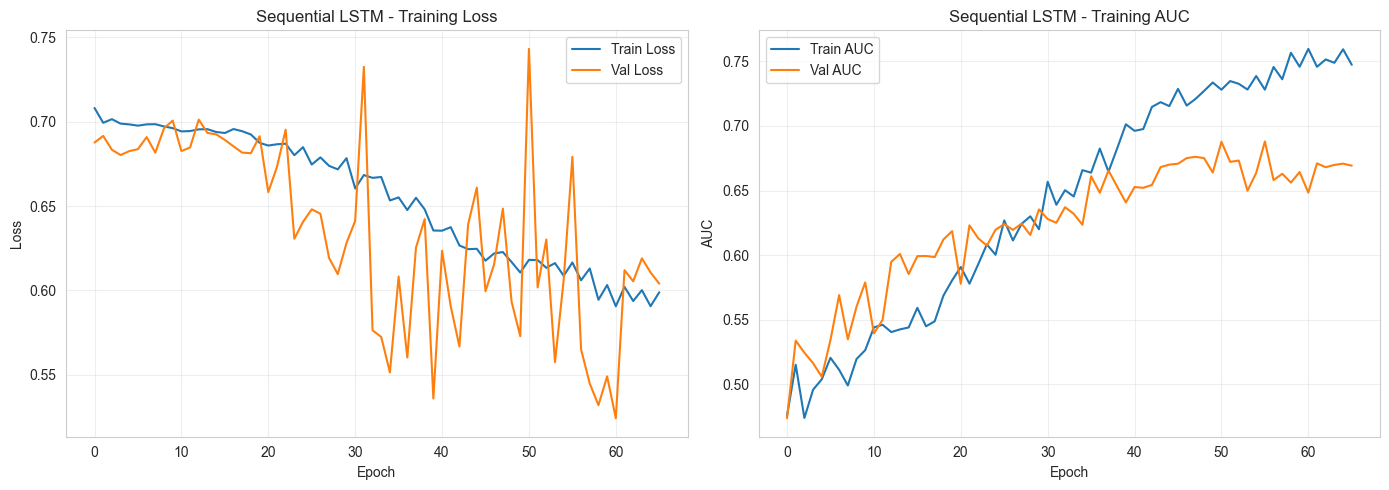

In [16]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_lstm)
weights = compute_class_weight('balanced', classes=classes, y=y_train_lstm)
class_weights_lstm = dict(zip(classes.astype(int), weights))
print(f'Class weights: {class_weights_lstm}')

lstm_model = LSTMModel(
    lstm_units_1=32,
    lstm_units_2=16,
    dense_units=8,
    dropout_rate=0.4,
    learning_rate=0.0005,
)
lstm_model.build_model((X_train_seq.shape[1], X_train_seq.shape[2]))
lstm_model.model.summary()

lstm_history = lstm_model.fit(
    X_train_seq, y_train_lstm,
    epochs=100, batch_size=32,
    class_weight=class_weights_lstm,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(lstm_history.history['loss'], label='Train Loss')
ax1.plot(lstm_history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Sequential LSTM - Training Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(lstm_history.history['auc'], label='Train AUC')
ax2.plot(lstm_history.history['val_auc'], label='Val AUC')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Sequential LSTM - Training AUC')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

lstm_proba = lstm_model.predict_proba(X_test_seq)

print('Sequential LSTM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(y_test_lstm, lstm_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(y_test_lstm, lstm_proba):.4f}')
print()
print(classification_report(y_test_lstm, (lstm_proba >= 0.5).astype(int),
                             target_names=['Non-Default', 'Default']))

Sequential LSTM - Test Set Performance:
  AUC-ROC: 0.6463
  AUC-PR: 0.1777

              precision    recall  f1-score   support

 Non-Default       0.92      0.67      0.78      1059
     Default       0.17      0.55      0.26       132

    accuracy                           0.66      1191
   macro avg       0.55      0.61      0.52      1191
weighted avg       0.84      0.66      0.72      1191



### 8b. Hybrid LSTM

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 100, 38)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 100, 38)   │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 100, 38)   │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 100)       │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 100, 32)   │      9,088 │ masking[0][0],    │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 100, 32)   │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 16)        │      3,136 │ dropout_3[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        328 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8)         │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24)        │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         17 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,969 (50.66 KB)

 Trainable params: 12,969 (50.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 60s 269ms/step - auc: 0.6312 - loss: 0.6833 - val_auc: 0.8154 - val_loss: 0.5932 - learning_rate: 5.0000e-04
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 33s 257ms/step - auc: 0.7183 - loss: 0.6300 - val_auc: 0.8577 - val_loss: 0.5680 - learning_rate: 5.0000e-04
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 299ms/step - auc: 0.7453 - loss: 0.6001 - val_auc: 0.8799 - val_loss: 0.5340 - learning_rate: 5.0000e-04
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 35s 275ms/step - auc: 0.7935 - loss: 0.5608 - val_auc: 0.8951 - val_loss: 0.4904 - learning_rate: 5.0000e-04
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 34s 271ms/step - auc: 0.8053 - loss: 0.5387 - val_auc: 0.9074 - val_loss: 0.4679 - learning_rate: 5.0000e-04
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 32s 249ms/step - auc: 0.8493 - loss: 0.4915 - val_auc: 0.9168 - val_loss: 0.4316 - learning_rate: 5.0000e-04
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 249ms/step - auc: 0.8599 - loss: 0.4688 - val_auc: 0.92

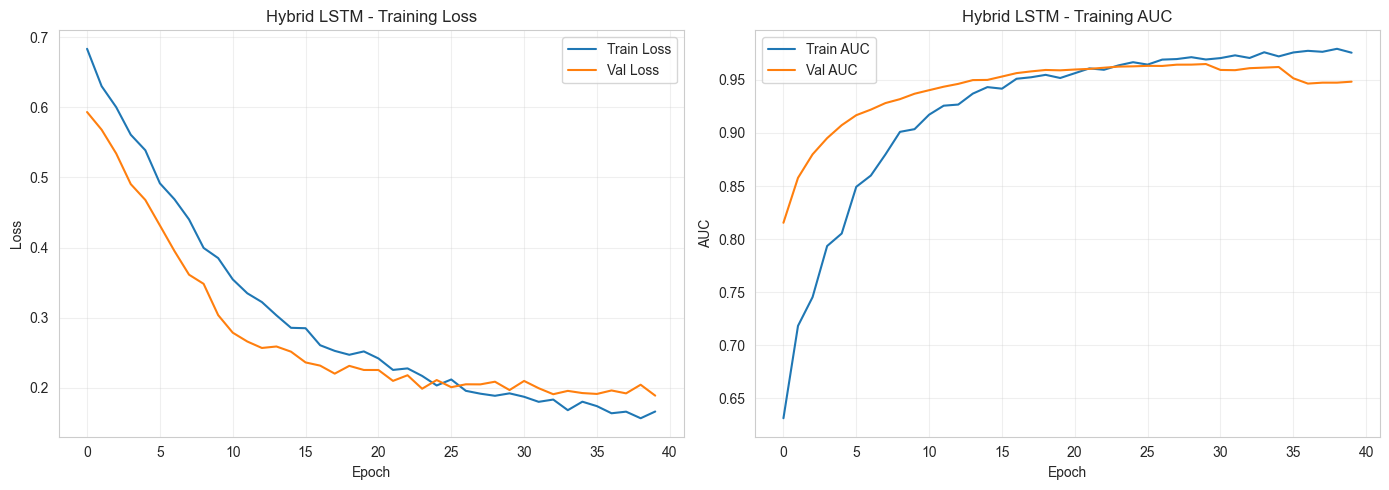

In [18]:
hybrid_model = HybridLSTMModel(
    lstm_units_1=32,
    lstm_units_2=16,
    dense_units=16,
    dropout_rate=0.4,
    learning_rate=0.0005,
)
hybrid_model.build_model((X_train_seq.shape[1], X_train_seq.shape[2]),
                         X_train_static_lstm.shape[1])
hybrid_model.model.summary()

hybrid_history = hybrid_model.fit(
    X_train_seq, X_train_static_lstm, y_train_lstm,
    epochs=100, batch_size=32,
    class_weight=class_weights_lstm,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(hybrid_history.history['loss'], label='Train Loss')
ax1.plot(hybrid_history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Hybrid LSTM - Training Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(hybrid_history.history['auc'], label='Train AUC')
ax2.plot(hybrid_history.history['val_auc'], label='Val AUC')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Hybrid LSTM - Training AUC')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
hybrid_proba = hybrid_model.predict_proba(X_test_seq, X_test_static_lstm)

print('Hybrid LSTM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(y_test_lstm, hybrid_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(y_test_lstm, hybrid_proba):.4f}')
print()
print(classification_report(y_test_lstm, (hybrid_proba >= 0.5).astype(int),
                             target_names=['Non-Default', 'Default']))

Hybrid LSTM - Test Set Performance:
  AUC-ROC: 0.9558
  AUC-PR: 0.7023

              precision    recall  f1-score   support

 Non-Default       0.98      0.90      0.94      1059
     Default       0.51      0.87      0.65       132

    accuracy                           0.89      1191
   macro avg       0.75      0.88      0.79      1191
weighted avg       0.93      0.89      0.91      1191



## 9. Model Comparison

In [61]:
# All models evaluated on y_test_lstm (same users as static models — confirmed by assertion above)
import importlib
import seqcredit_model.credit_model as credit_model
importlib.reload(credit_model)
ModelEvaluator = credit_model.ModelEvaluator

evaluator = ModelEvaluator(y_test_lstm)
evaluator.add_model('Logistic Regression', lr_proba)
evaluator.add_model('XGBoost', xgb_proba)
evaluator.add_model('Random Forest', rf_proba)
evaluator.add_model('LightGBM', lgbm_proba)
evaluator.add_model('Sequential LSTM', lstm_proba)
evaluator.add_model('Hybrid LSTM', hybrid_proba)

comparison = evaluator.get_comparison_table()
print('\nModel Comparison (Test Set):')
print(comparison.round(4).to_string())


Model Comparison (Test Set):
                     AUC-ROC  AUC-PR      F1  Precision  Recall  Accuracy
Model                                                                    
Logistic Regression   0.4846  0.1154  0.1440     0.1111  0.2045    0.7305
XGBoost               0.4816  0.1086  0.0956     0.0929  0.0985    0.7935
Random Forest         0.4779  0.1103  0.0993     0.0882  0.1136    0.7716
LightGBM              0.4731  0.1119  0.0993     0.0882  0.1136    0.7716
Sequential LSTM       0.6463  0.1777  0.2640     0.1734  0.5530    0.6583
Hybrid LSTM           0.9558  0.7023  0.6461     0.5134  0.8712    0.8942


In [62]:
# Cross-validation comparison (static models only; LSTM uses single split)
cv_results = {}
for name, cv in [('Logistic Regression', lr_cv), ('XGBoost', xgb_cv),
                 ('Random Forest', rf_cv), ('LightGBM', lgbm_cv)]:
    cv_results[name] = {
        metric: f"{np.mean(values):.4f} +/- {np.std(values):.4f}"
        for metric, values in cv.items()
    }

cv_df = pd.DataFrame(cv_results).T
print('\nCross-Validation Results (5-Fold, static models):')
print(cv_df.to_string())


Cross-Validation Results (5-Fold, static models):
                               auc_roc             auc_pr                 f1           accuracy
Logistic Regression  0.9808 +/- 0.0060  0.8641 +/- 0.0451  0.7048 +/- 0.0284  0.9099 +/- 0.0113
XGBoost              0.9812 +/- 0.0048  0.8984 +/- 0.0190  0.7749 +/- 0.0162  0.9479 +/- 0.0049
Random Forest        0.9807 +/- 0.0054  0.8908 +/- 0.0222  0.7579 +/- 0.0314  0.9443 +/- 0.0081
LightGBM             0.9845 +/- 0.0031  0.9084 +/- 0.0161  0.7839 +/- 0.0260  0.9483 +/- 0.0063


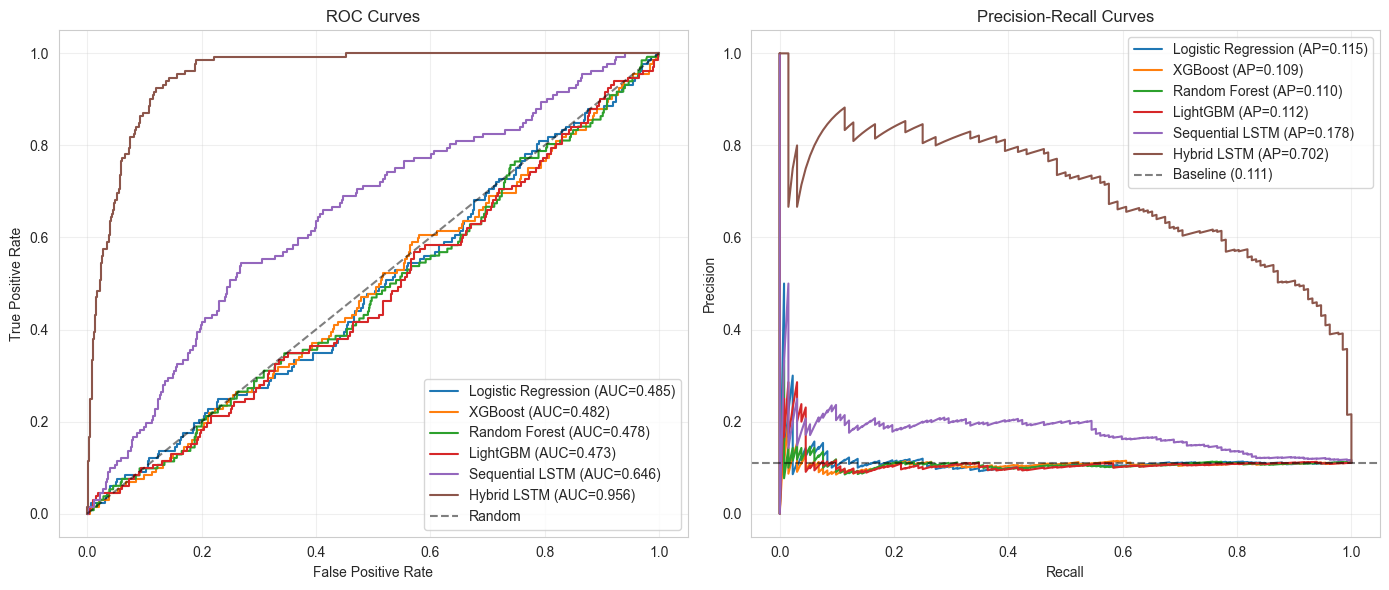

In [63]:
# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
evaluator.plot_roc_curves(ax=ax1)
evaluator.plot_pr_curves(ax=ax2)
plt.tight_layout()
plt.show()

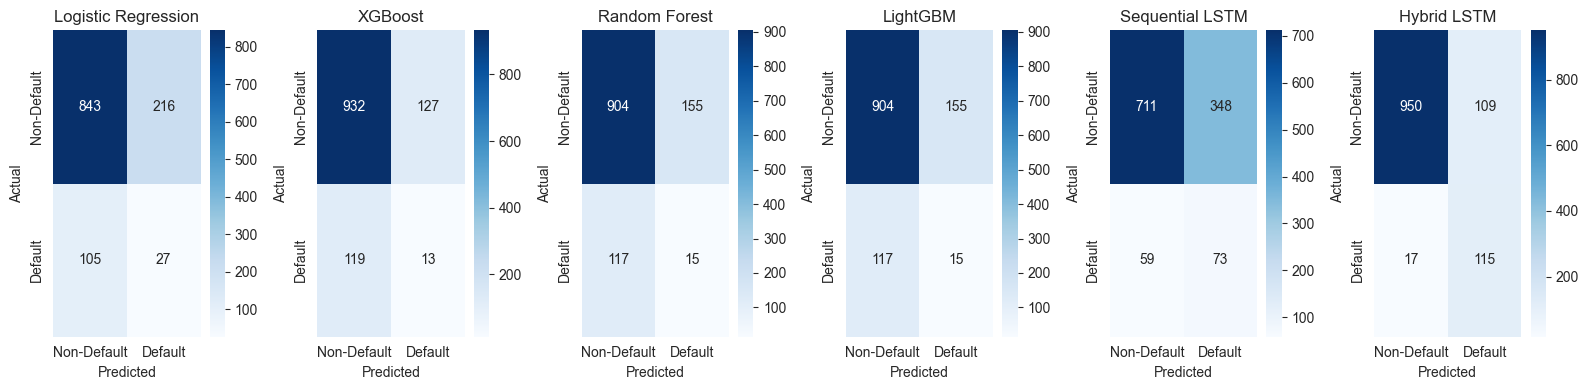

In [64]:
# Confusion matrices
evaluator.plot_confusion_matrices(figsize=(16, 4))
plt.show()

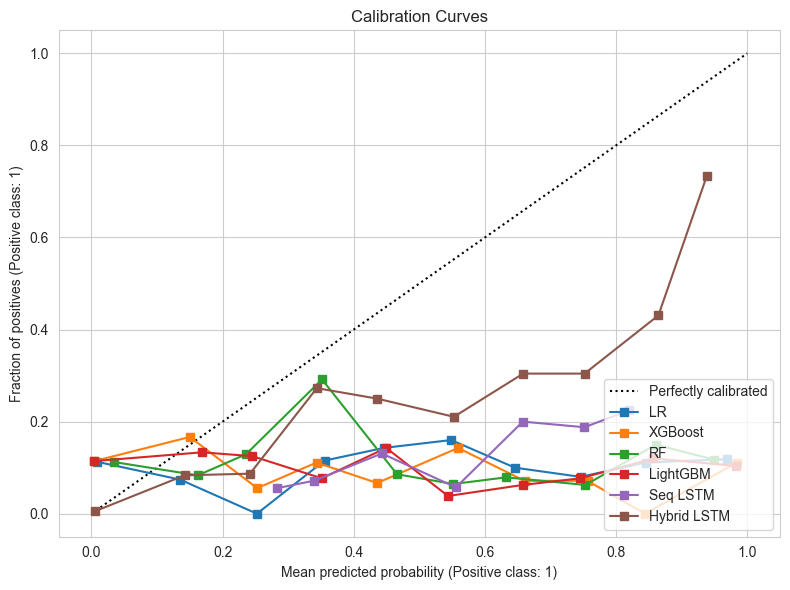

In [65]:
# Calibration curves
from sklearn.calibration import CalibrationDisplay
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in [('LR', lr_proba), ('XGBoost', xgb_proba),
                    ('RF', rf_proba), ('LightGBM', lgbm_proba),
                    ('Seq LSTM', lstm_proba), ('Hybrid LSTM', hybrid_proba)]:
    CalibrationDisplay.from_predictions(
        y_test_lstm, proba, n_bins=10, ax=ax, name=name
    )
ax.set_title('Calibration Curves')
plt.tight_layout()
plt.show()

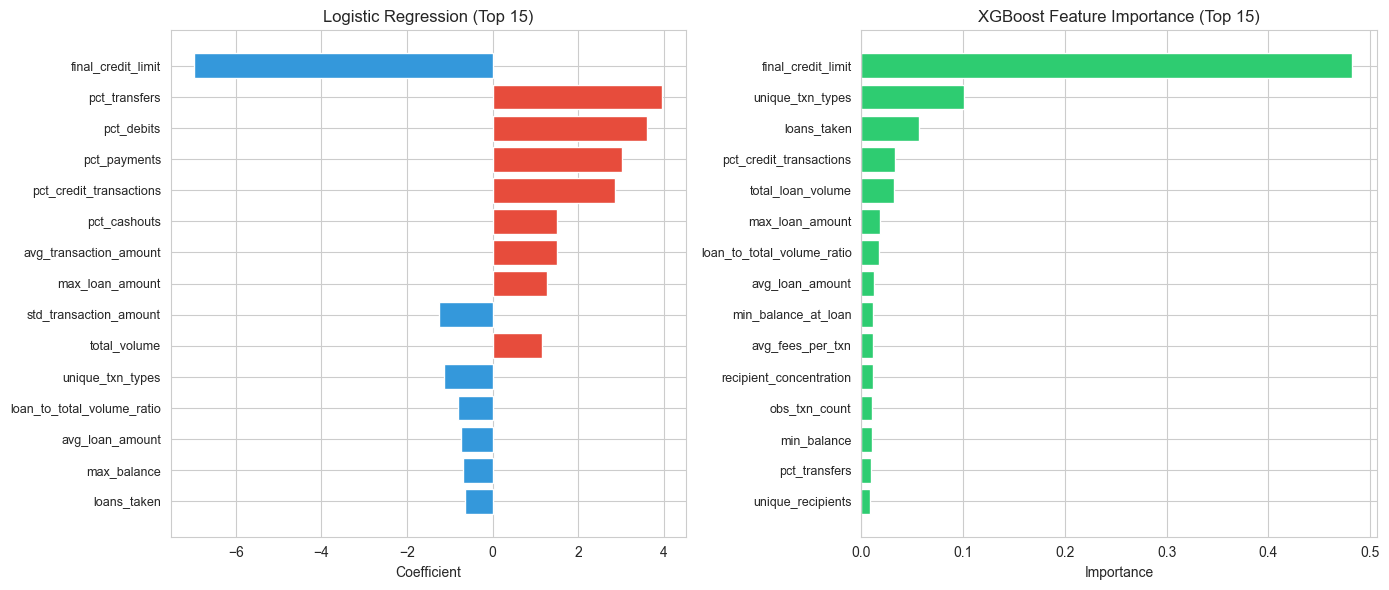

In [66]:
# Feature importance comparison (LR vs XGBoost)
evaluator.plot_feature_importance_comparison(
    lr_coefs, xgb_importance, top_n=15
)
plt.show()

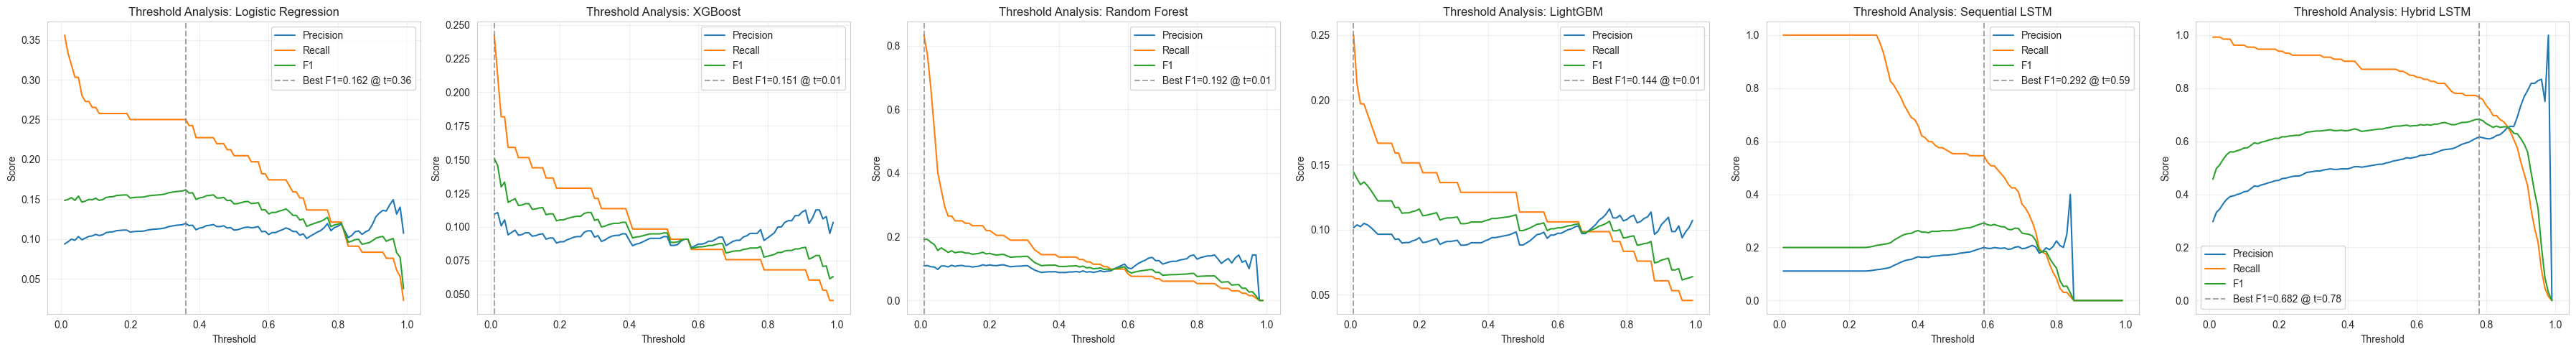

In [67]:
# Threshold analysis for each model
model_names = ['Logistic Regression', 'XGBoost', 'Random Forest', 'LightGBM',
               'Sequential LSTM', 'Hybrid LSTM']
fig, axes = plt.subplots(1, len(model_names), figsize=(6 * len(model_names), 5))
for ax, name in zip(axes, model_names):
    evaluator.plot_threshold_analysis(name, ax=ax)
plt.tight_layout()
plt.show()

In [68]:
# Classification reports
evaluator.print_classification_reports()


  Logistic Regression
              precision    recall  f1-score   support

 Non-Default       0.89      0.80      0.84      1059
     Default       0.11      0.20      0.14       132

    accuracy                           0.73      1191
   macro avg       0.50      0.50      0.49      1191
weighted avg       0.80      0.73      0.76      1191


  XGBoost
              precision    recall  f1-score   support

 Non-Default       0.89      0.88      0.88      1059
     Default       0.09      0.10      0.10       132

    accuracy                           0.79      1191
   macro avg       0.49      0.49      0.49      1191
weighted avg       0.80      0.79      0.80      1191


  Random Forest
              precision    recall  f1-score   support

 Non-Default       0.89      0.85      0.87      1059
     Default       0.09      0.11      0.10       132

    accuracy                           0.77      1191
   macro avg       0.49      0.48      0.48      1191
weighted avg       0.80

## 10. Analysis

- **AUC-PR** is the primary metric given ~11% default rate (class imbalance).
- **Static models** (LR, RF, XGBoost, LightGBM) operate on 40 aggregate features; LightGBM and RF typically lead this group.
- **Sequential LSTM** uses only per-transaction sequences â€” captures temporal patterns but loses aggregate context.
- **Hybrid LSTM** fuses both: LSTM-encoded sequences concatenated with static features before the output layer. This is the most expressive architecture.
- Balance-related features dominate importance rankings across all static models.

In [69]:
# Save comparison table
comparison.to_csv(os.path.join(project_root, 'data/model_comparison.csv'))
print('Comparison table saved to data/model_comparison.csv')

Comparison table saved to data/model_comparison.csv


## 11. Save Models & Arrays
Save all trained models and test arrays for the analysis notebook.

In [71]:
# Save all trained models for use in the analysis notebook
import os
import joblib
models_dir = os.path.join(project_root, "models")
os.makedirs(models_dir, exist_ok=True)

# Save wrapper state directly to avoid class-identity issues after importlib.reload
joblib.dump({"state": lr_model.__dict__}, os.path.join(models_dir, "lr_model.pkl"))
joblib.dump({"state": xgb_model.__dict__}, os.path.join(models_dir, "xgb_model.pkl"))
joblib.dump({"state": rf_model.__dict__}, os.path.join(models_dir, "rf_model.pkl"))
joblib.dump({"state": lgbm_model.__dict__}, os.path.join(models_dir, "lgbm_model.pkl"))

# Keras models
lstm_model.save(os.path.join(models_dir, "lstm_model.keras"))
hybrid_model.save(os.path.join(models_dir, "hybrid_model.keras"))

print("All models saved to", models_dir)


All models saved to c:\Users\Dell\Projects\seqcredit-model\models


In [72]:
# Save LSTM test/train arrays so the analysis notebook can load them without re-building
np.savez_compressed(
    os.path.join(project_root, "data", "lstm_test_arrays.npz"),
    X_train_seq=X_train_seq,
    X_test_seq=X_test_seq,
    X_train_static=X_train_static_lstm,
    X_test_static=X_test_static_lstm,
    y_train=y_train_lstm,
    y_test=y_test_lstm,
)
print("LSTM arrays saved to data/lstm_test_arrays.npz")


LSTM arrays saved to data/lstm_test_arrays.npz
